# Publication Data Exploration

This notebook generates the synthetic data plots shown in our paper.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

from src.data.data_layout import SyntheticDataLayout, PROJECT_ROOT
from src.utils.hydra_config_helpers import get_experiment_data_provider, get_synthetic_data_provider
from src.plot.publication_plots import (
    plot_component_distributions,
    plot_component_realisations,
    plot_fixed_effect_realisation,
    plot_group_realisations,
    plot_split_groups,
    set_publication_style,
)
from src.task.few_shot import FewShot
from src.task.in_context import InContext

set_publication_style()


FIG_DIR = PROJECT_ROOT / "plots" / "publication_data_exploration"
FIXED_EFFECT_DIR = FIG_DIR / "fixed_effect"
RANDOM_EFFECT_DIR = FIG_DIR / "random_effect"
NOISE_DIR = FIG_DIR / "noise"
EXPERIMENT_DIRS = {
    "gp_gaussian": FIG_DIR / "gp_gaussian",
    "brownian_gaussian": FIG_DIR / "brownian_gaussian",
}

for directory in [FIG_DIR, FIXED_EFFECT_DIR, RANDOM_EFFECT_DIR, NOISE_DIR, *EXPERIMENT_DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 0

# Set it to `True` only when you want a quick layout preview with much smaller data.
USE_FAST_PREVIEW = False
PREVIEW_OVERRIDES = [
    "data.n_subjects=40",
    "data.n_observations_per_subject=60",
    "data.split_params.n_validation_groups=8",
    "data.split_params.n_test_groups=8",
    "data.split_params.n_support_validation=10",
    "data.split_params.n_support_test=10",
]
CASE_OVERRIDES = PREVIEW_OVERRIDES if USE_FAST_PREVIEW else []

# These are the in-context and few-shot configurations used for the main synthetic experiments.
IN_CONTEXT_TASK = InContext(training_context_size=0.5, validation_size=0.25, test_size=0.25)
FEW_SHOT_TASK = FewShot(
    n_validation_groups=8 if USE_FAST_PREVIEW else 100,
    n_test_groups=8 if USE_FAST_PREVIEW else 100,
    n_support_validation=10 if USE_FAST_PREVIEW else 20,
    n_support_test=10 if USE_FAST_PREVIEW else 20,
)

In [2]:
def _first_seed(seed_df_dict, seed=SEED):
    return seed_df_dict[seed]


def _case_dict(name, provider, raw_df, split_df, source):
    return {
        "name": name,
        "provider": provider,
        "raw": raw_df,
        "in_context": split_df[(IN_CONTEXT_TASK.name, SEED)],
        "few_shot": split_df[(FEW_SHOT_TASK.name, SEED)],
        "source": source,
    }


def _read_or_generate_raw(provider, experiment_name):
    raw_path = Path(
        SyntheticDataLayout.get_raw_df_path(
            experiment_name=experiment_name,
            fixed_effect=provider.fixed_effect,
            seed=SEED,
        )
    )
    if raw_path.exists() and not USE_FAST_PREVIEW:
        return pd.read_parquet(raw_path), f"raw: {raw_path.relative_to(PROJECT_ROOT)}"

    raw_df = _first_seed(provider.generate_raw_data(save_data=False))
    return raw_df, "raw: generated in memory"


def _read_or_generate_splits(provider, raw_df, experiment_name):
    split_frames = {}
    missing_tasks = []
    sources = []

    for task in [IN_CONTEXT_TASK, FEW_SHOT_TASK]:
        split_path = Path(
            SyntheticDataLayout.get_split_df_path(
                task=task,
                experiment_name=experiment_name,
                fixed_effect=provider.fixed_effect,
                seed=SEED,
            )
        )
        if split_path.exists() and not USE_FAST_PREVIEW:
            split_frames[(task.name, SEED)] = pd.read_parquet(split_path)
            sources.append(f"{task.name}: {split_path.relative_to(PROJECT_ROOT)}")
        else:
            missing_tasks.append(task)

    if missing_tasks:
        provider.raw_df_dict = {SEED: raw_df}
        generated = provider.generate_split_data(tasks=missing_tasks, save_data=False)
        split_frames.update(generated)
        sources.extend([f"{task.name}: generated in memory" for task in missing_tasks])

    return split_frames, "; ".join(sources)


def synthetic_case(
    name,
    fixed_effect="steps_1D",
    random_effect="GP_rbf",
    noise="homoscedastic_gaussian",
    overrides=None,
):
    provider = get_synthetic_data_provider(
        experiment_name=name,
        fixed_effect=fixed_effect,
        random_effect=random_effect,
        noise=noise,
        seeds=[SEED],
        additional_overrides=CASE_OVERRIDES + (overrides or []),
    )
    raw_df = _first_seed(provider.generate_raw_data(save_data=False))
    split_df = provider.generate_split_data(
        tasks=[IN_CONTEXT_TASK, FEW_SHOT_TASK],
        save_data=False,
    )
    return _case_dict(name, provider, raw_df, split_df, "generated from synthetic/base")


def experiment_case(name, fixed_effect="steps_1D", overrides=None):
    provider = get_experiment_data_provider(
        experiment_name=name,
        experiment_type="synthetic",
        additional_overrides=[
            f"data/synthetic/fixed_effect={fixed_effect}",
            f"data.generation_seed_list=[{SEED}]",
        ]
        + CASE_OVERRIDES
        + (overrides or []),
    )
    raw_df, raw_source = _read_or_generate_raw(provider, name)
    split_df, split_source = _read_or_generate_splits(provider, raw_df, name)
    return _case_dict(name, provider, raw_df, split_df, f"{raw_source}; {split_source}")


def summarize_case(case):
    provider = case["provider"]
    return pd.Series(
        {
            "experiment": case["name"],
            "fixed_effect": provider.fixed_effect.name,
            "random_effect": provider.random_effect.name,
            "noise": provider.noise.name,
            "feature_dimension": provider.fixed_effect.feature_dimension,
            "n_rows": len(case["raw"]),
            "n_tasks": case["raw"]["group"].nunique(),
            "source": case["source"],
        }
    )


def close_all():
    plt.close("all")

## Build Cases

In [3]:
cases = {
    "steps_1D": synthetic_case(
        "publication_steps_1D",
        fixed_effect="steps_1D",
        random_effect="zero",
        noise="homoscedastic_gaussian",
    ),
    "steps_2D": synthetic_case(
        "publication_steps_2D",
        fixed_effect="steps_2D",
        random_effect="zero",
        noise="homoscedastic_gaussian",
    ),
    "gp_rbf": synthetic_case(
        "publication_gp_rbf",
        fixed_effect="zero_1D",
        random_effect="GP_rbf",
        noise="zero",
    ),
    "brownian": synthetic_case(
        "publication_brownian",
        fixed_effect="zero_1D",
        random_effect="brownian_motion",
        noise="zero",
    ),
    "gaussian_noise": synthetic_case(
        "publication_gaussian_noise",
        fixed_effect="zero_1D",
        random_effect="zero",
        noise="homoscedastic_gaussian",
    ),
    "lognormal_noise": synthetic_case(
        "publication_lognormal_noise",
        fixed_effect="zero_1D",
        random_effect="zero",
        noise="lognormal",
    ),
    "gp_gaussian": experiment_case("gp_gaussian", fixed_effect="steps_1D"),
    "brownian_gaussian": experiment_case("brownian_gaussian", fixed_effect="steps_1D"),
}

pd.DataFrame([summarize_case(case) for case in cases.values()])

,experiment,fixed_effect,random_effect,noise,feature_dimension,n_rows,n_tasks,source
0,publication_steps_1D,steps_1D,zero,homoscedastic_gaussian,1,60000,600,generated from synthetic/base
1,publication_steps_2D,steps_2D,zero,homoscedastic_gaussian,2,60000,600,generated from synthetic/base
2,publication_gp_rbf,zero_1D,GP_rbf,zero_noise,1,60000,600,generated from synthetic/base
3,publication_brownian,zero_1D,brownian_motion,zero_noise,1,60000,600,generated from synthetic/base
4,publication_gaussian_noise,zero_1D,zero,homoscedastic_gaussian,1,60000,600,generated from synthetic/base
5,publication_lognormal_noise,zero_1D,zero,lognormal,1,60000,600,generated from synthetic/base
6,gp_gaussian,steps_1D,GP_rbf,homoscedastic_gaussian,1,60000,600,raw: data\raw\synthetic\gp_gaussian\steps_1D\s...
7,brownian_gaussian,steps_1D,brownian_motion,homoscedastic_gaussian,1,60000,600,raw: data\raw\synthetic\brownian_gaussian\step...


## Fixed Effects: Steps 1D and Steps 2D

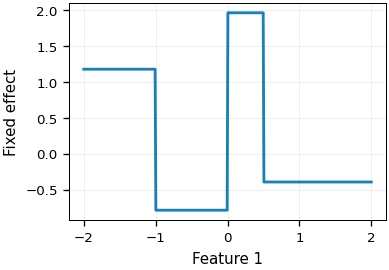

In [4]:
case = cases["steps_1D"]
fixed_effect = case["provider"].fixed_effect

plot_fixed_effect_realisation(
    fixed_effect,
    save_path=FIXED_EFFECT_DIR / "steps_1D-fixed_effect.pdf",
);

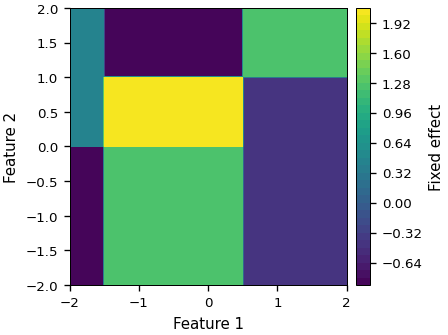

In [5]:
case = cases["steps_2D"]
fixed_effect = case["provider"].fixed_effect

plot_fixed_effect_realisation(
    fixed_effect,
    save_path=FIXED_EFFECT_DIR / "steps_2D-fixed_effect.pdf",
);

## Random Effects: GP RBF and Brownian Motion

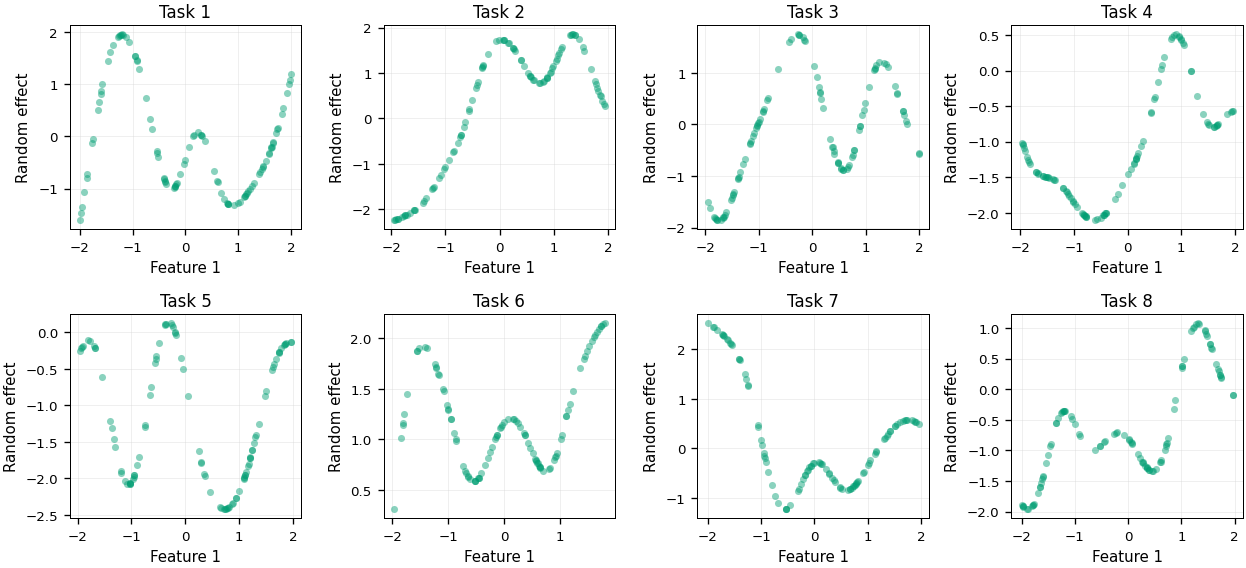

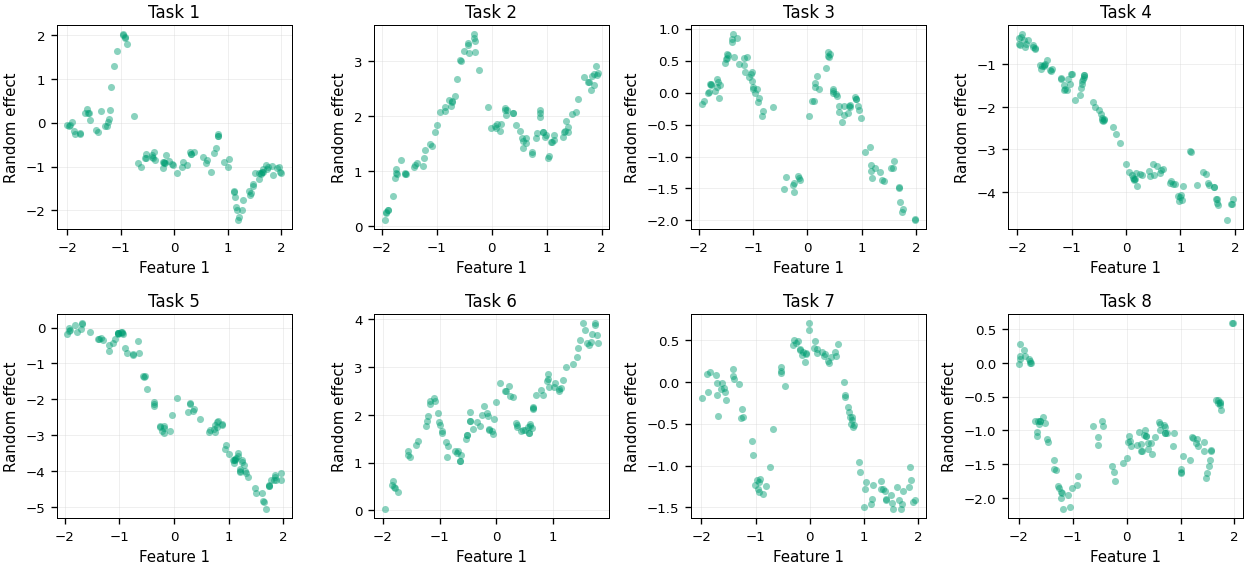

In [6]:
for key, label in [("gp_rbf", "GP RBF random effect"), ("brownian", "Brownian random effect")]:
    case = cases[key]
    plot_component_realisations(
        case["raw"],
        component_column="[RANDOM_EFFECT]",
        component_label="Random effect",
        y_label="Random effect",
        num_groups=8,
        experiment_name=label,
        save_path=RANDOM_EFFECT_DIR / f"{key}-realisations.pdf",
    );

## Noise: Lognormal

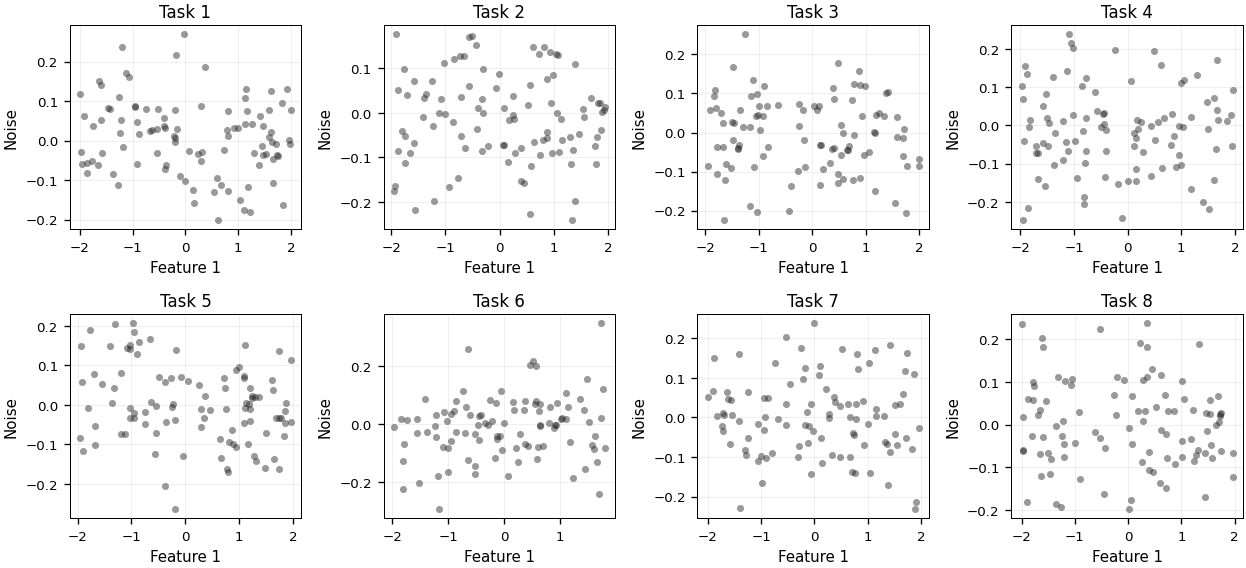

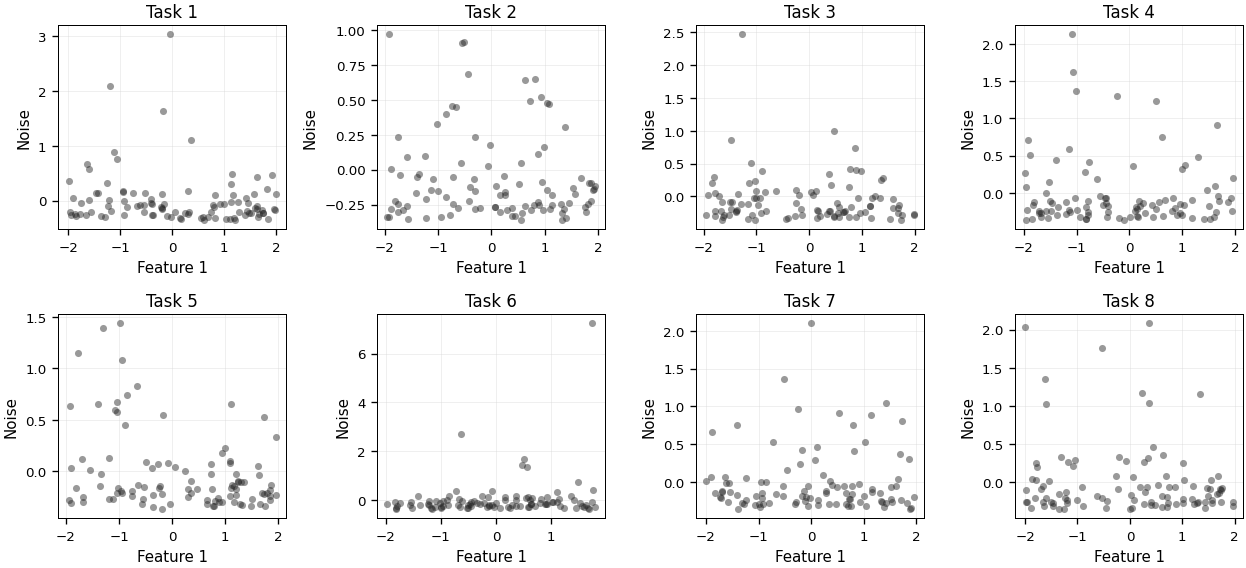

In [7]:
for key, label in [("gaussian_noise", "Gaussian noise"), ("lognormal_noise", "Lognormal noise")]:
    case = cases[key]
    plot_component_realisations(
        case["raw"],
        component_column="[NOISE]",
        component_label="Noise",
        num_groups=8,
        y_label="Noise",
        experiment_name=f"{label} realisations",
        save_path=NOISE_DIR / f"{key}-realisations.pdf",
    );

## Experiment Presets: GP Gaussian and Brownian Gaussian

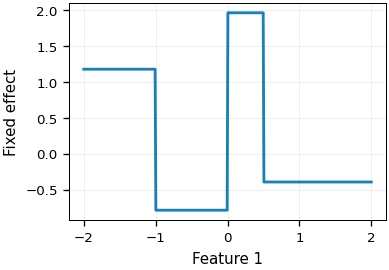

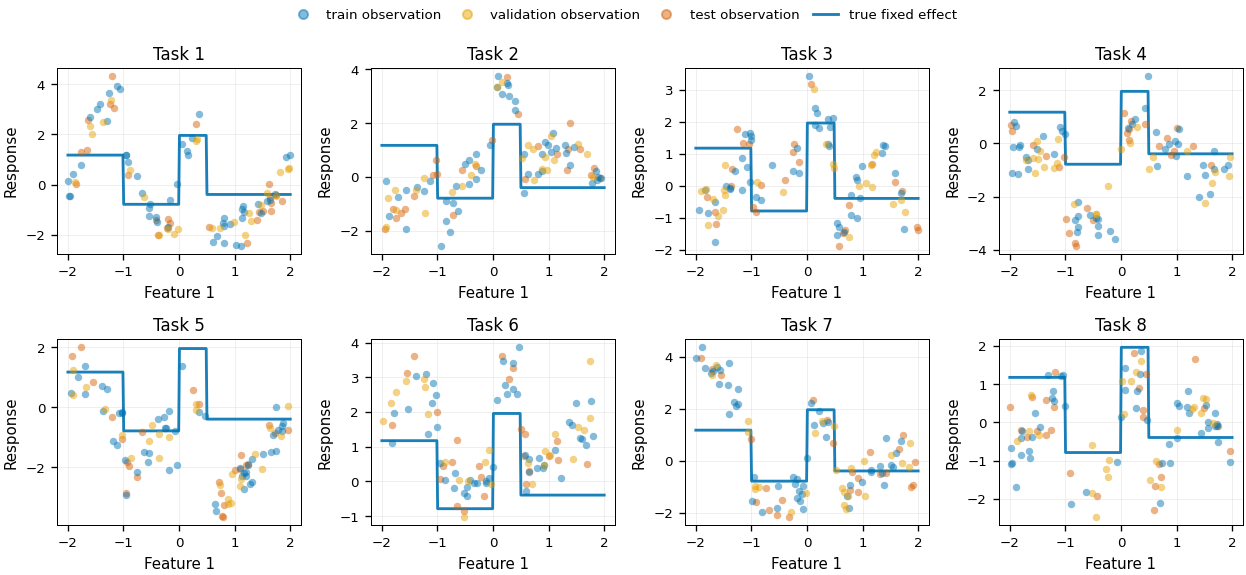

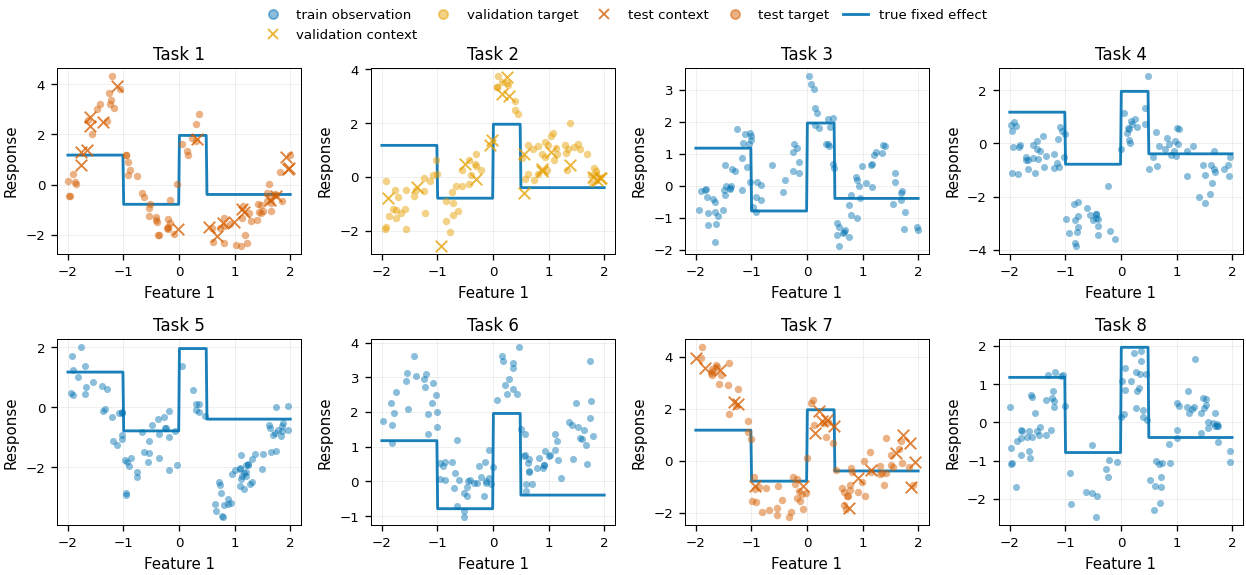

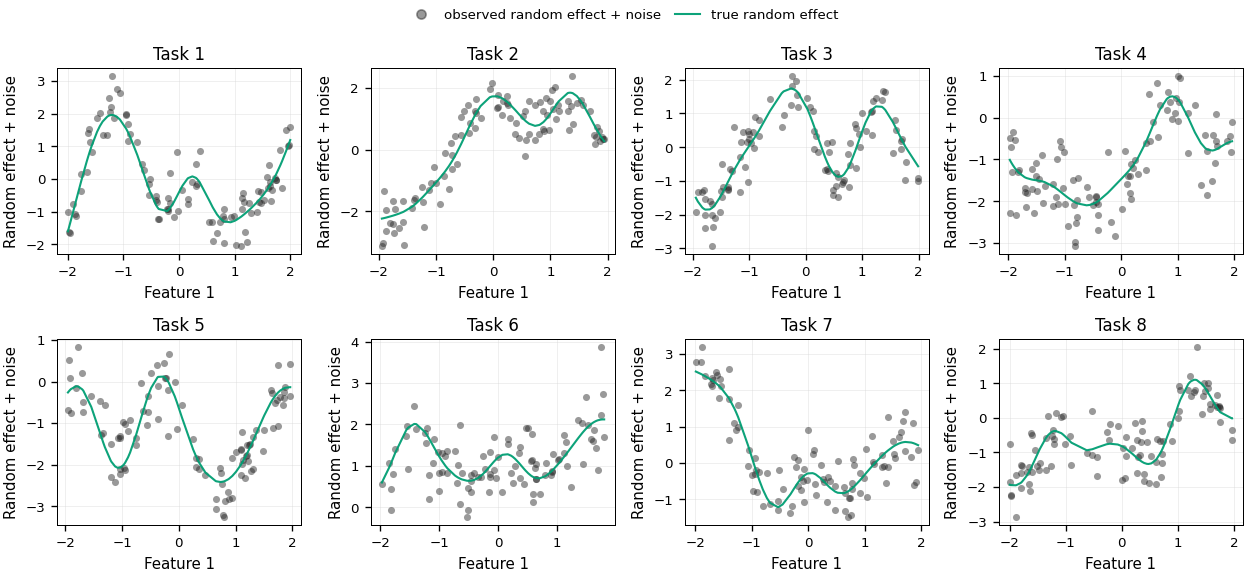

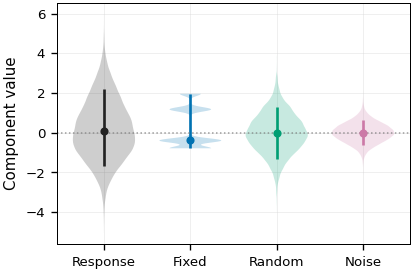

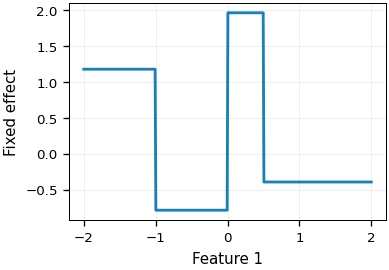

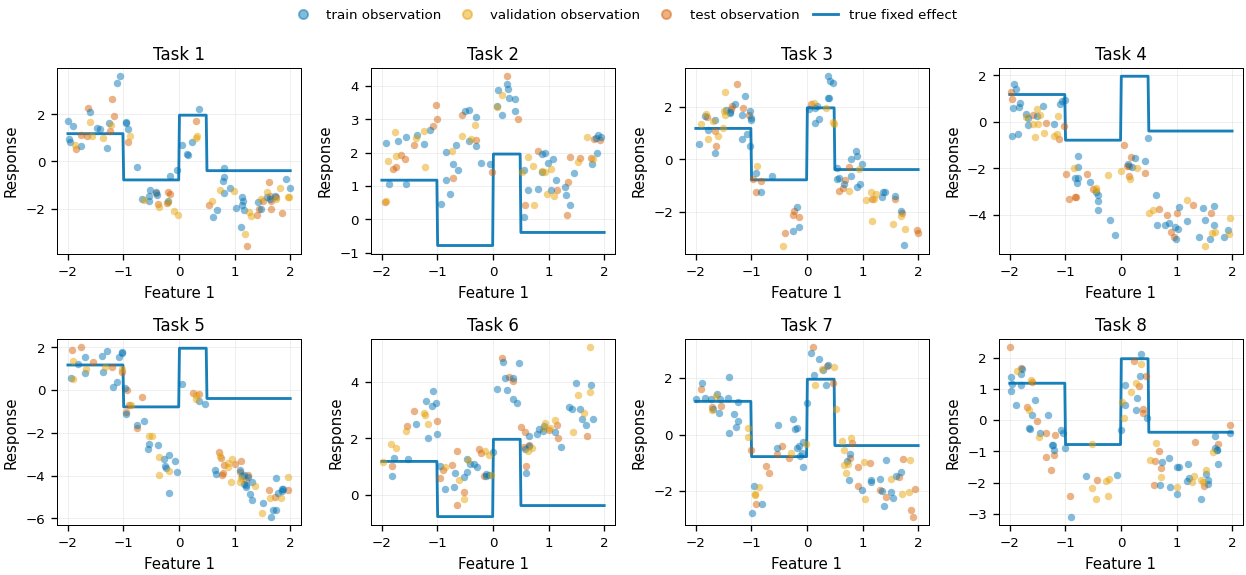

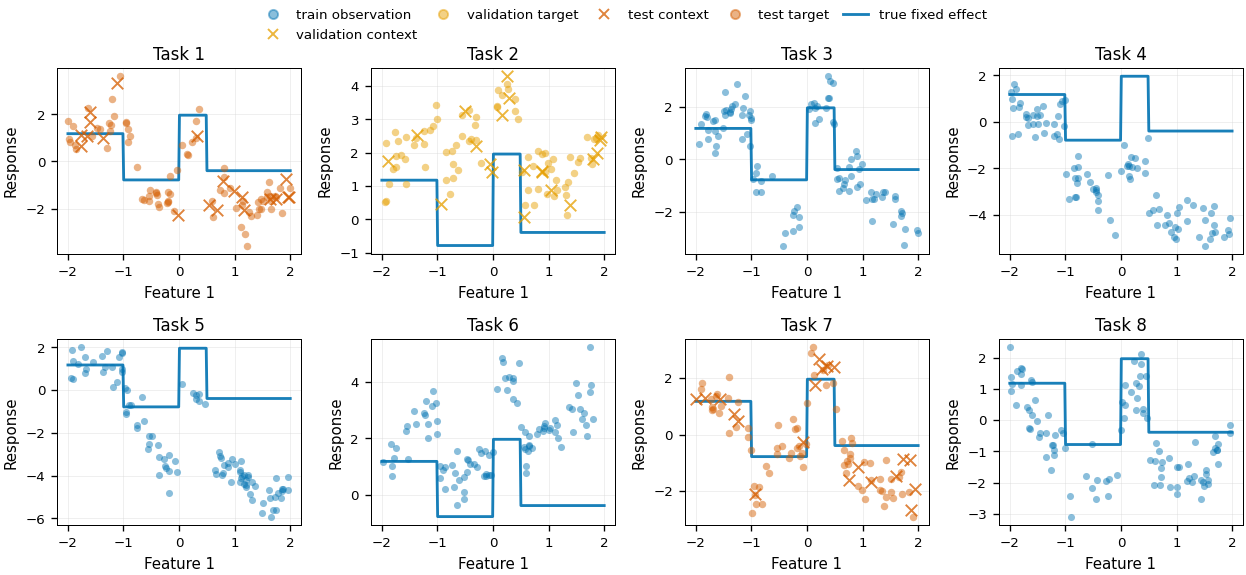

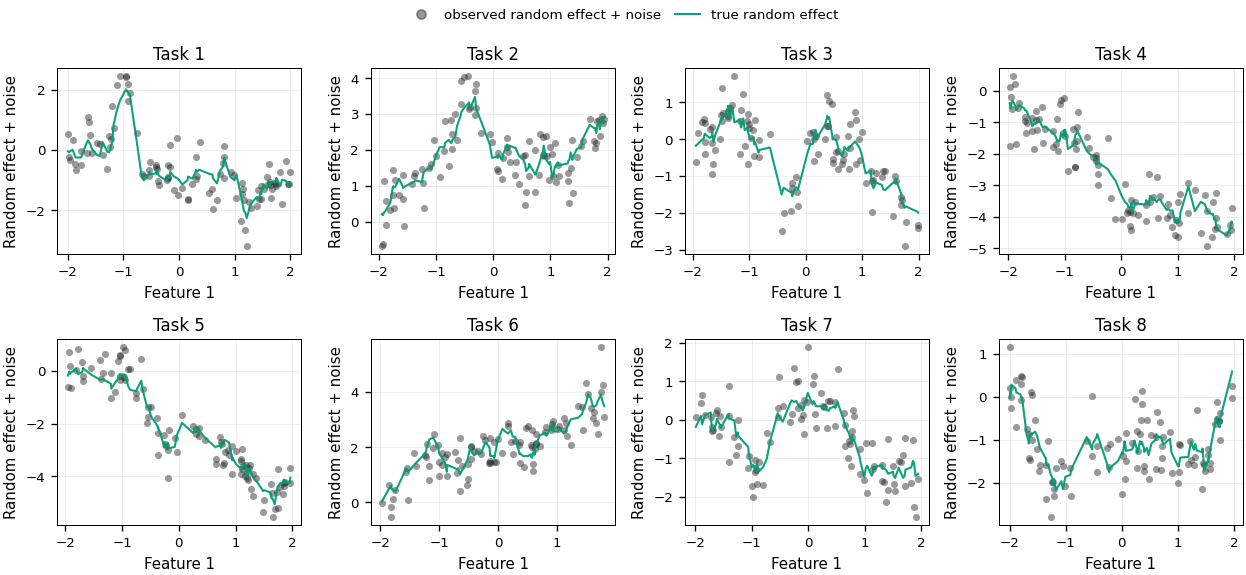

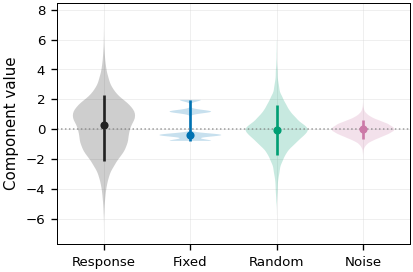

In [8]:
for key, label in [("gp_gaussian", "gp_gaussian"), ("brownian_gaussian", "brownian_gaussian")]:
    case = cases[key]
    fixed_effect = case["provider"].fixed_effect
    fixed_effect_name = fixed_effect.name
    experiment_dir = EXPERIMENT_DIRS[key]
    plot_fixed_effect_realisation(
        fixed_effect,
        save_path=experiment_dir / f"{fixed_effect_name}-fixed_effect.pdf",
    );
    plot_split_groups(
        case["in_context"],
        fixed_effect=fixed_effect,
        task=IN_CONTEXT_TASK,
        num_groups=8,
        y_label="Response",
        experiment_name=f"{label}: in-context split",
        save_path=experiment_dir / f"{fixed_effect_name}-in_context-split.pdf",
    );
    plot_split_groups(
        case["few_shot"],
        fixed_effect=fixed_effect,
        task=FEW_SHOT_TASK,
        num_groups=8,
        y_label="Response",
        experiment_name=f"{label}: few-shot split",
        save_path=experiment_dir / f"{fixed_effect_name}-few_shot-split.pdf",
    );
    plot_group_realisations(
        case["raw"],
        fixed_effect=fixed_effect,
        y_mode="response_minus_fixed_effect",
        y_label="Random effect + noise",
        observed_label="observed random effect + noise",
        num_groups=8,
        experiment_name=f"{label}: random-effect/noise raw view",
        save_path=experiment_dir / f"{fixed_effect_name}-random_effect-noise.pdf",
    );
    plot_component_distributions(
        case["raw"],
        y_label="Component value",
        experiment_name=f"{label}: component distributions",
        save_path=experiment_dir / f"{fixed_effect_name}-component_value-distribution.pdf",
    );